In [24]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
model, params = MLFlowRegistry().load_model('crowd_counting', version='1', run_id='7db01084ce8d43efaf49124078dc2d5f')

Model loaded from /teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:1//data/model.pt2


In [15]:
model.predict(torch.randn(1,3,512,256))

(5329.599609375,
 array([[[0.00719509, 0.00318791, 0.        , ..., 0.03701922,
          0.04953378, 0.05579106],
         [0.00467112, 0.        , 0.        , ..., 0.031651  ,
          0.04494873, 0.05159761],
         [0.        , 0.        , 0.        , ..., 0.02091455,
          0.03577865, 0.0432107 ],
         ...,
         [0.03556823, 0.02753073, 0.01145571, ..., 0.04838497,
          0.05217705, 0.05407309],
         [0.0497691 , 0.04214751, 0.02690433, ..., 0.05735609,
          0.05975844, 0.06095962],
         [0.05686954, 0.0494559 , 0.03462863, ..., 0.06184165,
          0.06354914, 0.06440289]]], shape=(1, 512, 256), dtype=float32))

In [19]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='fit')

In [21]:
sample, target, count = helpers.get_sample_from_dm(datamodule)
sample.shape

torch.Size([1, 3, 672, 992])

In [30]:
result_count, result  = model.predict(sample)

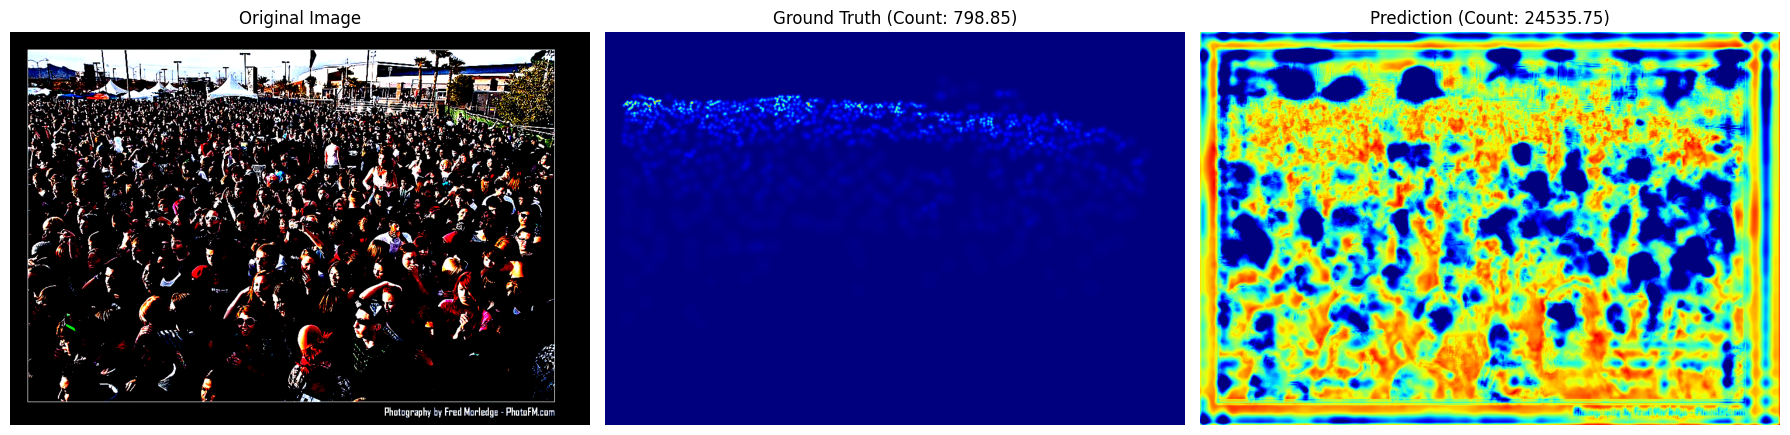

In [31]:
vis.visualize_sample(sample, target, result, count, result_count, )